In [9]:
import math

data=[
    ["Sunny","Hot","High","Weak","No"],
    ["Sunny","Hot","High","Strong","No"],
    ["Overcast","Hot","High","Weak","Yes"],
    ["Rain","Mild","High","Weak","Yes"],
    ["Rain","Cool","Normal","Weak","Yes"],
    ["Rain","Cool","Normal","Strong","No"],
    ["Overcast","Cool","Normal","Strong","Yes"],
    ["Sunny","Mild","High","Weak","No"],
    ["Sunny","Cool","Normal","Weak","Yes"],
    ["Rain","Mild","Normal","Weak","Yes"],
    ["Sunny","Mild","Normal","Strong","Yes"],
    ["Overcast","Mild","High","Strong","Yes"],
    ["Overcast","Hot","Normal","Weak","Yes"],
    ["Rain","Mild","High","Strong","No"]
]

features=["Outlook","Temperature","Humidity","Windy"]
def entropy(data):
    labels=[row[-1] for row in data]
    counts={}
    for label in labels:
        counts[label]=counts.get(label, 0)+1
    total=len(labels)
    result=0
    for count in counts.values():
        probability=count/total
        result-=probability*math.log2(probability)
    return result

def information_gain(data, feature_index):
    total_entropy=entropy(data)
    values=set(row[feature_index] for row in data)
    weighted_entropy=0
    for value in values:
        subset=[row for row in data if row[feature_index] == value]
        weight=len(subset)/len(data)
        weighted_entropy+=weight*entropy(subset)
    return total_entropy-weighted_entropy

def best_feature(data,features):
    gains=[]
    for i in range(len(features)):
        gain=information_gain(data, i)
        gains.append(gain)
        print(features[i], "Information Gain =",round(gain, 3))
    return gains.index(max(gains))

def id3(data, features):
    labels=[row[-1] for row in data]
    if len(set(labels))==1:
        return labels[0]
    if len(features)==0:
        return max(set(labels),key=labels.count)
    best_index = best_feature(data,features)
    best=features[best_index]
    tree={best: {}}
    values=set(row[best_index] for row in data)
    for value in values:
        subset=[row for row in data if row[best_index] == value]
        new_data=[row[:best_index] + row[best_index + 1:] for row in subset]
        new_features=(features[:best_index] +features[best_index + 1:])
        tree[best][value]=id3(new_data, new_features)
    return tree

tree=id3(data, features)
print("\nFinal Decision Tree:")
print(tree)

Outlook Information Gain = 0.247
Temperature Information Gain = 0.029
Humidity Information Gain = 0.152
Windy Information Gain = 0.048
Temperature Information Gain = 0.571
Humidity Information Gain = 0.971
Windy Information Gain = 0.02
Temperature Information Gain = 0.02
Humidity Information Gain = 0.02
Windy Information Gain = 0.971

Final Decision Tree:
{'Outlook': {'Sunny': {'Humidity': {'Normal': 'Yes', 'High': 'No'}}, 'Overcast': 'Yes', 'Rain': {'Windy': {'Strong': 'No', 'Weak': 'Yes'}}}}


Predicted: [0 0 1 1 1 0 1 0 1 1 1 1 1 0]
Actual:    [0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


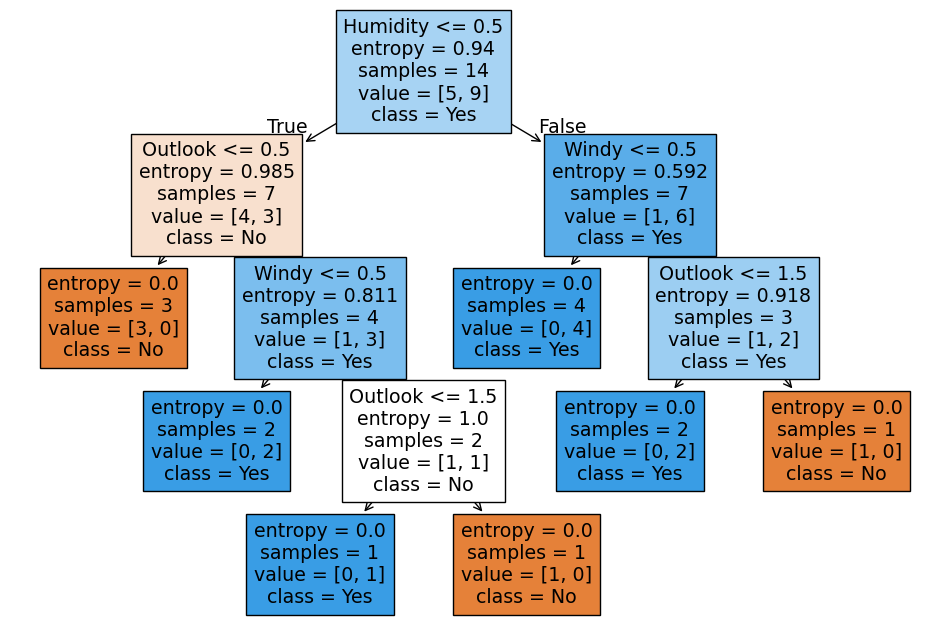

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

X = [
    [0,0, 0,0],
    [0,0, 0,1],
    [1,0, 0,0],
    [2,1, 0,0],
    [2,2,1,0],
    [2,2,1,1],
    [1,2,1,1],
    [0,1,0,0],
    [0,2,1,0],
    [2,1,1,0],
    [0,1,1,1],
    [1,1,0,1],
    [1,0,1,0],
    [2,1,0,1]
]

y = [
    0,0,1,1,1,0,1,
    0,1,1,1,1,1,0 ]

model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model.fit(X, y)
y_pred = model.predict(X)
print("Predicted:", y_pred)
print("Actual:   ", y)

plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=[
        "Outlook",
        "Temperature",
        "Humidity",
        "Windy"
    ],
    class_names=["No", "Yes"],
    filled=True
)
plt.show()